# Applying Dinomaly2 to BMAD

Runs the reproduced Dinomaly2 recipe (`src/models/dinomaly2.py`: same encoder,
two-stage bottleneck, context-aware recentering, and linear-attention decoder as
the MVTec-AD/VisA reproduction in `../dinomaly2_repro_mvtec_visa.ipynb`) against
each [BMAD](https://github.com/DorisBao/BMAD) modality, training one model per
modality. Each BMAD modality has no category dimension (see `bmad_eda.ipynb`),
so there is nothing to make multi-class over, unlike MVTec-AD/VisA.

Sections 1-6 run the MVTec/VisA architecture unchanged, to establish how the
validated pipeline performs out of the box on a different domain. Section 7
follows up with a targeted architecture change, motivated by where this
baseline under-performs (see section 5 and 6's analysis). Section 8 applies an
unrelated frozen-feature method (AnomalyDINO-DPMM) to the same six modalities
for comparison.

**Val vs. test.** Every BMAD modality ships its own val split, separate from
train and test (see `bmad_eda.ipynb` section 1), unlike the MVTec-AD/VisA
reproduction, which follows Dinomaly2's own script and only ever looks at test.
Here, every eval checkpoint scores both splits: val selects which checkpoint to
keep (`best_checkpoint.pt`, by val I-AUROC, the one metric available for every
modality), and test is what is reported in section 5. This keeps a run from
grading its own checkpoint choice against the number it is judged on.

**Seeds.** Per the advisor's instruction, reported test metrics are the mean
(and standard deviation) over `SEEDS` independent runs per modality, not a
single run -- each seed gets its own weight initialization, batch shuffling,
and (for section 7/8) DPMM initialization, with its own `best_val_iter` picked
independently. `SEEDS = [1, 2, 3]`, satisfying the "at least three" half of
the instruction. Sections 4, 5, 6, and 8 below report and analyze the full
three-seed results; section 7's architecture ablation uses a single seed
(`SEEDS[0]`) deliberately, as a controlled hypothesis test against one
baseline seed rather than a headline number (see section 7's own note).

**Time.** Each modality's training set is much smaller than MVTec-AD/VisA's
combined multi-class set (1.5k-26k images vs. approximately 140k), so
per-iteration training cost is lower. However, each eval checkpoint scores both
the val set and the full test set, and test sets range up to 17k images
(Chest). Eval time, not training time, dominated these runs and does not shrink
with `TOTAL_ITERS`. The full `SEEDS = [1, 2, 3]` campaign across sections 3 and
8 (six modalities, two methods, three seeds each) ran 2026-09-28 through
2026-10-03, roughly 116 hours of unattended wall-clock time, consistent with
the single-seed pilot's ~12-hour-per-method estimate tripled for the seed
sweep plus DPMM's own per-modality cost (DPMM's 40-epoch budget per seed runs
from under an hour for the smaller modalities to over 11 hours for OCT, whose
26k-image training set is the largest in the benchmark). Unlike the MVTec/VisA
reproduction, this is a first pass rather than a paper reproduction, so
`TOTAL_ITERS` is a judgment call, not a fixed target; see the note in the next
cell.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json, glob
sys.path.insert(0, '../..')  # notebooks/bmad/ -> repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.training.train_bmad import pick_device
device = pick_device()
print('device:', device)

device: mps


## 1. Run parameters

`TOTAL_ITERS = 5000` is a starting budget, not the MVTec/VisA reproduction's
40000: that number came from Dinomaly2's own README for a 15-class
multi-class MVTec-AD run, which has no equivalent here (each BMAD modality is
its own single-class problem, 1.5k-26k images). The MVTec-AD eval curve in
`../dinomaly2_repro_mvtec_visa.ipynb` was already within 0.003 I-AUROC of its
final value by iteration 5000 of 40000, which is why 5000 is a reasonable
first look rather than an arbitrary guess. It had not been checked against
BMAD's own convergence behavior prior to this run; section 4 evaluates that
directly from the loss and metric curves.

In [2]:
DEV = False   # True: ~150 iters/modality, sanity-checks the whole notebook end to end
MODALITIES = ['brain', 'liver', 'retina_resc', 'chest', 'histopathology', 'retina_oct']

BACKBONE = 'vit_base'

if DEV:
    TOTAL_ITERS, EVAL_EVERY, WARMUP = 150, 150, 20
    SEEDS = [1, 2]   # >1 seed even in DEV, to sanity-check the aggregation code path
else:
    TOTAL_ITERS, EVAL_EVERY, WARMUP = 5000, 1000, 100
    SEEDS = [1, 2, 3]

print(f'modalities: {MODALITIES}')
print(f'total_iters: {TOTAL_ITERS} | eval_every: {EVAL_EVERY} | warmup: {WARMUP} | seeds: {SEEDS}')

modalities: ['brain', 'liver', 'retina_resc', 'chest', 'histopathology', 'retina_oct']
total_iters: 5000 | eval_every: 1000 | warmup: 100 | seeds: [1, 2, 3]


## 2. Data check

Confirms BMAD is in place and prints split sizes before spending any GPU/MPS time. See `bmad_eda.ipynb` for the full per-modality breakdown (image properties, sample grids, mask coverage).

In [3]:
from src.data.bmad import load_modality, MODALITIES as MODALITY_CONFIGS, resolve_bmad_root

bmad_root = resolve_bmad_root()
print(f'BMAD root: {bmad_root}\n')
for name in MODALITIES:
    cfg = MODALITY_CONFIGS[name]
    train_data, val_data, test_data, has_masks = load_modality(name)
    print(f'{name:16s}  train={len(train_data):6d}  val={len(val_data):5d}  '
          f'test={len(test_data):6d}  masks={has_masks}')

BMAD root: /Users/toriav/Desktop/Erem/BC Cancer/Anomaly Detection/mammo-uad-2d3d/data/BMAD

brain             train=  7500  val=   83  test=  3715  masks=True
liver             train=  1542  val=  166  test=  1493  masks=True
retina_resc       train=  4297  val=  115  test=  1805  masks=True
chest             train=  8000  val= 1490  test= 17194  masks=False
histopathology    train=  5088  val=  236  test=  1997  masks=False
retina_oct        train= 26315  val=   32  test=   968  masks=False


## 3. Train + evaluate each modality, over `SEEDS`

One `train()` call per (modality, seed) pair (`src/training/train_bmad.py`, same
optimizer/schedule/loss as the MVTec/VisA reproduction). Checkpoints and
`history.json` land in `../../runs/bmad_dinomaly2_<modality>_seed<seed>_<timestamp>/`,
one directory per seed. `histories` is keyed `histories[modality][seed]`. Safe to
interrupt and rerun this cell; `load_history` below falls back to the latest run on
disk for any (modality, seed) pair not (re)trained in this kernel session.

In [4]:
from src.training.train_bmad import BMADConfig, train

histories = {name: {} for name in MODALITIES}
for name in MODALITIES:
    for seed in SEEDS:
        print(f'=== {name} (seed {seed}) ===')
        cfg = BMADConfig(
            modality=name, backbone=BACKBONE, total_iters=TOTAL_ITERS, eval_every=EVAL_EVERY,
            warmup_iters=WARMUP, seed=seed,
        )
        histories[name][seed] = train(cfg, device=device)

=== brain (seed 1) ===


/Users/toriav/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/toriav/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/toriav/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


device mps | modality brain (pixel masks: True) | backbone vit_base | trainable 60.0M
train images 7500 | val images 83 | test images 3715 | 468 batches/epoch -> 11 epochs
-> /Users/toriav/Desktop/Erem/BC Cancer/Anomaly Detection/mammo-uad-2d3d/runs/bmad_dinomaly2_brain_seed1_20260928_132918


  0%|          | 0/5000 [00:00<?, ?it/s]

[eval @ iter 1000 / epoch 3] val: I-AUROC 0.9120  I-AP 0.9263  I-F1 0.8791  P-AUROC 0.9802  P-AP 0.6885  P-AUPRO 0.8544
                             test: I-AUROC 0.9057  I-AP 0.9738  I-F1 0.9354  P-AUROC 0.9782  P-AP 0.7231  P-AUPRO 0.8220
[eval @ iter 2000 / epoch 5] val: I-AUROC 0.9056  I-AP 0.9200  I-F1 0.8602  P-AUROC 0.9831  P-AP 0.7033  P-AUPRO 0.8657
                             test: I-AUROC 0.9163  I-AP 0.9783  I-F1 0.9361  P-AUROC 0.9805  P-AP 0.7463  P-AUPRO 0.8398
[eval @ iter 3000 / epoch 7] val: I-AUROC 0.9283  I-AP 0.9413  I-F1 0.8791  P-AUROC 0.9829  P-AP 0.7172  P-AUPRO 0.8638
                             test: I-AUROC 0.9241  I-AP 0.9823  I-F1 0.9373  P-AUROC 0.9806  P-AP 0.7514  P-AUPRO 0.8356
[eval @ iter 4000 / epoch 9] val: I-AUROC 0.9207  I-AP 0.9342  I-F1 0.8913  P-AUROC 0.9829  P-AP 0.7064  P-AUPRO 0.8544
                             test: I-AUROC 0.9180  I-AP 0.9798  I-F1 0.9359  P-AUROC 0.9806  P-AP 0.7442  P-AUPRO 0.8347
[eval @ iter 5000 / epoch 11] val: I

...

[eval @ iter 1000 / epoch 1] val: I-AUROC 0.9896  I-AP 0.9966  I-F1 0.9796
                             test: I-AUROC 0.9778  I-AP 0.9922  I-F1 0.9633
[eval @ iter 2000 / epoch 2] val: I-AUROC 0.9948  I-AP 0.9983  I-F1 0.9796
                             test: I-AUROC 0.9778  I-AP 0.9921  I-F1 0.9629
[eval @ iter 3000 / epoch 2] val: I-AUROC 0.9896  I-AP 0.9968  I-F1 0.9787
                             test: I-AUROC 0.9827  I-AP 0.9941  I-F1 0.9658
[eval @ iter 4000 / epoch 3] val: I-AUROC 1.0000  I-AP 1.0000  I-F1 1.0000
                             test: I-AUROC 0.9781  I-AP 0.9926  I-F1 0.9615
[eval @ iter 5000 / epoch 4] val: I-AUROC 1.0000  I-AP 1.0000  I-F1 1.0000
                             test: I-AUROC 0.9792  I-AP 0.9930  I-F1 0.9615
done in 98.7 min  ->  /Users/toriav/Desktop/Erem/BC Cancer/Anomaly Detection/mammo-uad-2d3d/runs/bmad_dinomaly2_retina_oct_seed1_20260929_214742
=== retina_oct (seed 2) ===
device mps | modality retina_oct (pixel masks: False) | backbone vit_bas

  0%|          | 0/5000 [00:00<?, ?it/s]

[eval @ iter 1000 / epoch 1] val: I-AUROC 0.9844  I-AP 0.9948  I-F1 0.9796
                             test: I-AUROC 0.9729  I-AP 0.9906  I-F1 0.9575
[eval @ iter 2000 / epoch 2] val: I-AUROC 0.9844  I-AP 0.9951  I-F1 0.9600
                             test: I-AUROC 0.9778  I-AP 0.9923  I-F1 0.9615
[eval @ iter 3000 / epoch 2] val: I-AUROC 1.0000  I-AP 1.0000  I-F1 1.0000
                             test: I-AUROC 0.9837  I-AP 0.9945  I-F1 0.9691
[eval @ iter 4000 / epoch 3] val: I-AUROC 1.0000  I-AP 1.0000  I-F1 1.0000
                             test: I-AUROC 0.9804  I-AP 0.9932  I-F1 0.9641
[eval @ iter 5000 / epoch 4] val: I-AUROC 0.9844  I-AP 0.9948  I-F1 0.9796
                             test: I-AUROC 0.9816  I-AP 0.9938  I-F1 0.9646
done in 98.4 min  ->  /Users/toriav/Desktop/Erem/BC Cancer/Anomaly Detection/mammo-uad-2d3d/runs/bmad_dinomaly2_retina_oct_seed2_20260929_232649
=== retina_oct (seed 3) ===
device mps | modality retina_oct (pixel masks: False) | backbone vit_bas

  0%|          | 0/5000 [00:00<?, ?it/s]

[eval @ iter 1000 / epoch 1] val: I-AUROC 0.9844  I-AP 0.9948  I-F1 0.9796
                             test: I-AUROC 0.9777  I-AP 0.9922  I-F1 0.9607
[eval @ iter 2000 / epoch 2] val: I-AUROC 0.9896  I-AP 0.9966  I-F1 0.9796
                             test: I-AUROC 0.9773  I-AP 0.9923  I-F1 0.9622
[eval @ iter 3000 / epoch 2] val: I-AUROC 0.9896  I-AP 0.9968  I-F1 0.9787
                             test: I-AUROC 0.9800  I-AP 0.9932  I-F1 0.9658
[eval @ iter 4000 / epoch 3] val: I-AUROC 0.9896  I-AP 0.9966  I-F1 0.9796
                             test: I-AUROC 0.9828  I-AP 0.9941  I-F1 0.9640
[eval @ iter 5000 / epoch 4] val: I-AUROC 1.0000  I-AP 1.0000  I-F1 1.0000
                             test: I-AUROC 0.9830  I-AP 0.9944  I-F1 0.9649
done in 98.1 min  ->  /Users/toriav/Desktop/Erem/BC Cancer/Anomaly Detection/mammo-uad-2d3d/runs/bmad_dinomaly2_retina_oct_seed3_20260930_010534


### Results

Re-run from here without retraining by loading the latest `history.json` per modality off disk. This is useful for checking progress from a second notebook while the cell above is still training, or after a kernel restart.

In [5]:
def load_history(history_or_none, modality, seed):
    if history_or_none is not None:
        return history_or_none
    matches = sorted(glob.glob(f'../../runs/bmad_dinomaly2_{modality}_seed{seed}_*'))
    if not matches:
        return None
    return json.load(open(f'{matches[-1]}/history.json'))

histories = {
    name: {seed: load_history(histories.get(name, {}).get(seed), name, seed) for seed in SEEDS}
    for name in MODALITIES
}
for name in MODALITIES:
    parts = [f"seed {seed}: {len(h['evals'])} eval checkpoint(s)" if h else f"seed {seed}: no run yet"
             for seed, h in histories[name].items()]
    print(f'{name:16s}  ' + ' | '.join(parts))

brain             seed 1: 5 eval checkpoint(s) | seed 2: 5 eval checkpoint(s) | seed 3: 5 eval checkpoint(s)
liver             seed 1: 5 eval checkpoint(s) | seed 2: 5 eval checkpoint(s) | seed 3: 5 eval checkpoint(s)
retina_resc       seed 1: 5 eval checkpoint(s) | seed 2: 5 eval checkpoint(s) | seed 3: 5 eval checkpoint(s)
chest             seed 1: 5 eval checkpoint(s) | seed 2: 5 eval checkpoint(s) | seed 3: 5 eval checkpoint(s)
histopathology    seed 1: 5 eval checkpoint(s) | seed 2: 5 eval checkpoint(s) | seed 3: 5 eval checkpoint(s)
retina_oct        seed 1: 5 eval checkpoint(s) | seed 2: 5 eval checkpoint(s) | seed 3: 5 eval checkpoint(s)


## 4. Loss and val/test I-AUROC curves

One panel per modality: training loss (left axis) plus val and test I-AUROC at each eval checkpoint (right axis), consistent color per modality with the EDA notebook's palette (fixed categorical order, `tab10`). Val tracking test closely is a good indication that the checkpoint `best_checkpoint.pt` picks (by val I-AUROC) will generalize; a val curve that diverges from test is worth a second look before trusting `best_val_iter`.

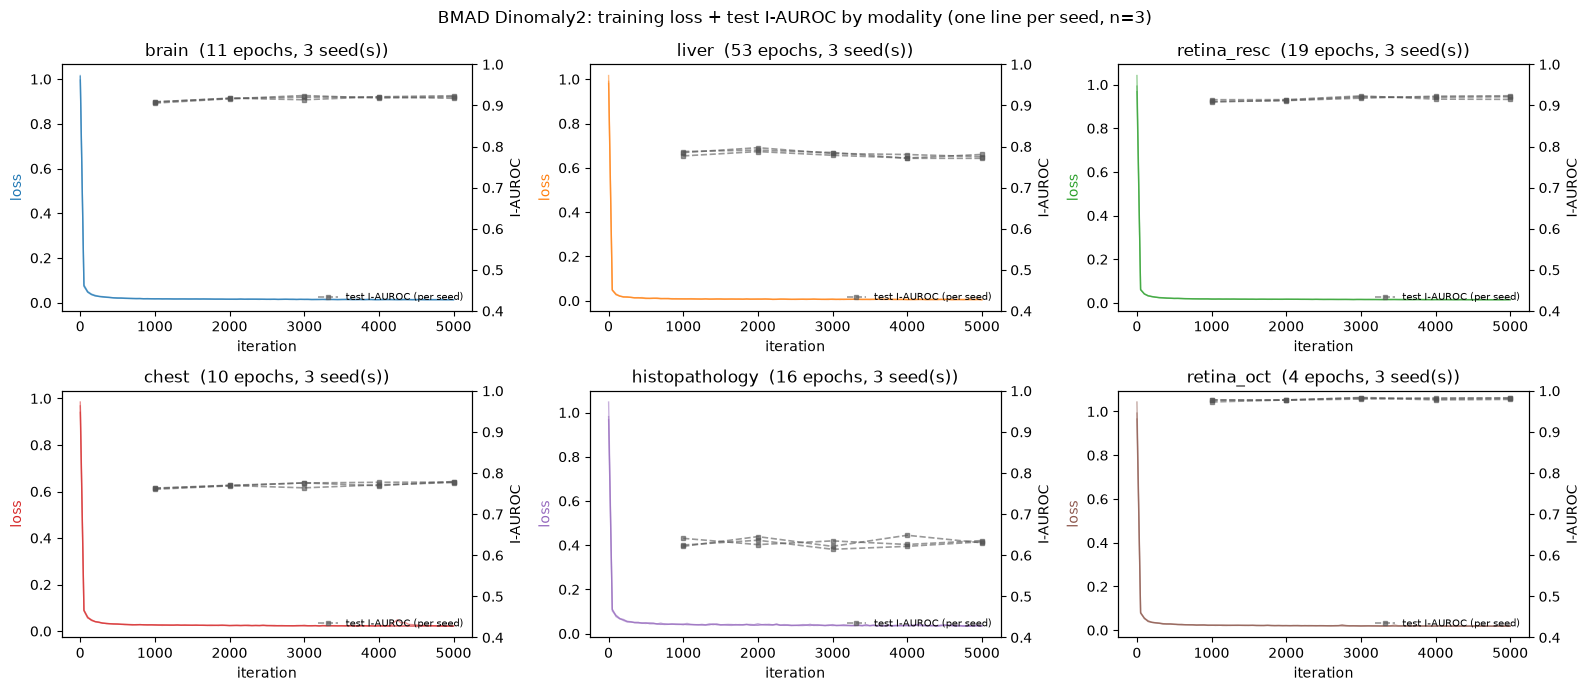

In [6]:
PALETTE = dict(zip(MODALITY_CONFIGS.keys(), plt.get_cmap('tab10').colors))

def plot_history(ax, history, name, color=None):
    """Single (modality, seed) history -- reused by section 7's single-seed comparison."""
    color = color or PALETTE.get(name, '#4c72b0')
    if history is None or not history['iters']:
        ax.set_title(f'{name}: no data yet')
        return
    ax.plot(history['iters'], history['loss'], color=color, lw=1.2)
    ax.set_xlabel('iteration')
    ax.set_ylabel('loss', color=color)
    title = f"{name}  ({history['epochs']} epochs)"
    if history['evals']:
        ax2 = ax.twinx()
        eval_iters = [e['iter'] for e in history['evals']]
        ax2.plot(eval_iters, [e['val']['auroc_sp'] for e in history['evals']],
                  color='#555555', lw=1.5, marker='o', ms=3, label='val I-AUROC')
        ax2.plot(eval_iters, [e['test']['auroc_sp'] for e in history['evals']],
                  color='#555555', lw=1.5, ls='--', marker='s', ms=3, label='test I-AUROC')
        ax2.set_ylabel('I-AUROC')
        ax2.set_ylim(0.4, 1.0)
        if history['best_val_iter'] is not None:
            ax2.axvline(history['best_val_iter'], color='#888888', lw=1, ls=':')
        ax2.legend(fontsize=7, frameon=False, loc='lower right')
    ax.set_title(title)

def plot_seed_histories(ax, seed_histories, name, color=None):
    """One line per seed (loss, left axis; test I-AUROC, right axis). Val curves and
    best_val_iter markers are dropped here (they differ per seed and would overplot);
    see plot_history above for the single-seed detail view section 7 uses."""
    color = color or PALETTE.get(name, '#4c72b0')
    valid = {s: h for s, h in seed_histories.items() if h and h['iters']}
    if not valid:
        ax.set_title(f'{name}: no data yet')
        return
    for h in valid.values():
        ax.plot(h['iters'], h['loss'], color=color, lw=1.0, alpha=0.5)
    ax.set_xlabel('iteration')
    ax.set_ylabel('loss', color=color)
    any_h = next(iter(valid.values()))
    ax.set_title(f"{name}  ({any_h['epochs']} epochs, {len(valid)} seed(s))")

    ax2 = ax.twinx()
    for i, h in enumerate(valid.values()):
        if h['evals']:
            eval_iters = [e['iter'] for e in h['evals']]
            ax2.plot(eval_iters, [e['test']['auroc_sp'] for e in h['evals']],
                      color='#555555', lw=1.2, ls='--', marker='s', ms=3, alpha=0.6,
                      label='test I-AUROC (per seed)' if i == 0 else None)
    ax2.set_ylabel('I-AUROC')
    ax2.set_ylim(0.4, 1.0)
    handles, labels = ax2.get_legend_handles_labels()
    if handles:
        ax2.legend(fontsize=7, frameon=False, loc='lower right')

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, name in zip(axes.flat, MODALITIES):
    plot_seed_histories(ax, histories.get(name, {}), name)
fig.suptitle(f'BMAD Dinomaly2: training loss + test I-AUROC by modality (one line per seed, n={len(SEEDS)})')
fig.tight_layout()

**Analysis.** Reading each modality's three overlaid test I-AUROC curves (one per
seed) against the 5000-iteration budget set in section 1:

- **Brain and RESC converge early, OCT fastest of all.** Brain's test I-AUROC stays
  within a roughly 0.906-0.924 band from iteration 1000 onward in every seed,
  oscillating without a clear trend. RESC's test I-AUROC climbs mildly across
  checkpoints in two of three seeds (0.909 to 0.921, 0.910 to 0.924) but is
  essentially flat in the third (0.914 to 0.915); either way it settles in a band
  comparable to Brain's. OCT is the clearest early-converger: every seed's test
  I-AUROC is already above 0.97 by iteration 1000 and stays there, with only minor
  movement after.
- **Liver peaks early and ends lower, which is a different story from "flat."** All
  three seeds show the same shape: test I-AUROC rises from iteration 1000 to a peak
  at iteration 2000 (0.788, 0.791, 0.797 across the three seeds), then sits lower
  than that peak by iteration 5000 in every seed (0.781, 0.771, 0.775). `best_val_iter`
  lands on iteration 2000 in all three seeds -- the one modality in this table where
  checkpoint selection agrees exactly across seeds, because the peak is in the same
  place in every one of them. This reads as mild overfitting past iteration 2000
  rather than the plateau the single-seed pilot suggested.
- **Chest trends upward in every seed.** Test I-AUROC rises from the first checkpoint
  to the last in all three runs (0.761 to 0.779, 0.764 to 0.778, 0.763 to 0.777),
  with a small mid-training dip in two of the three seeds rather than a perfectly
  monotonic climb, but none plateauing by iteration 5000. This is the one modality
  where a longer run at the current architecture would most likely still move the
  number, consistently across seeds.
- **Histopathology is flat and noisy in every seed, with no two seeds agreeing on
  where the checkpoint lands.** Test I-AUROC bounces within roughly a 0.61-0.65 band
  with no directional trend in any of the three runs, and `best_val_iter` falls at
  iteration 1000, 3000, and 4000 respectively -- consistent with selecting among
  noise rather than tracking a real peak.
- **Both val/test asymmetries flagged in the single-seed pilot hold in every seed,
  not just one.** RESC's val I-AUROC sits one to two points below its test I-AUROC at
  every checkpoint in all three seeds (a pessimistic bias). OCT's val I-AUROC reaches
  0.98-1.00 in every seed while test holds near 0.97-0.98 (consistent with the
  32-image val split being too small to be a reliable ceiling; see section 6). Seeing
  both asymmetries reproduce across three independent runs rather than appearing
  once is good evidence they are structural properties of these two modalities' val
  splits, not artifacts of a single run.

## 5. Metrics summary (mean ± std over `SEEDS`)

For each seed, the reported checkpoint is that seed's own `best_val_iter` (the
checkpoint that scored highest on that seed's val split), not the last iteration
trained. Each modality's row is then the mean and standard deviation of that
per-seed test metric, over however many of `SEEDS` have a completed run --
matching the advisor's instruction directly, rather than a single run's number.
Image-level metrics (I-AUROC/I-AP/I-F1) are reported for every modality;
pixel-level metrics (P-AUROC/P-AP/P-AUPRO) only for Brain/Liver/RESC, which are the
only three with pixel masks (see `bmad_eda.ipynb` section 1). `NaN` for the other
three is expected, not missing data. `results` also carries `_mean`/`_std` numeric
columns (not shown in the display table) for downstream use, e.g. section 8's
comparison against AnomalyDINO-DPMM.

In [7]:
def best_eval(history):
    """Single (modality, seed) history -- reused by sections 7 and 8."""
    if not history or not history['evals']:
        return None
    if history['best_val_iter'] is None:
        return history['evals'][-1]
    return next(e for e in history['evals'] if e['iter'] == history['best_val_iter'])

METRIC_SPECS = [
    ('val_I_AUROC', 'val', 'auroc_sp'), ('test_I_AUROC', 'test', 'auroc_sp'),
    ('val_I_AP', 'val', 'ap_sp'), ('test_I_AP', 'test', 'ap_sp'),
    ('val_I_F1', 'val', 'f1_sp'), ('test_I_F1', 'test', 'f1_sp'),
    ('test_P_AUROC', 'test', 'auroc_px'), ('test_P_AP', 'test', 'ap_px'),
    ('test_P_F1', 'test', 'f1_px'), ('test_P_AUPRO', 'test', 'aupro_px'),
]

def format_mean_std(vals):
    vals = [v for v in vals if v is not None]
    if not vals:
        return None
    if len(vals) == 1:
        return f'{vals[0]:.4f} (n=1)'
    return f'{np.mean(vals):.4f} ± {np.std(vals):.4f} (n={len(vals)})'

def summarize_across_seeds(seed_histories):
    """dict[seed -> history] -> one row: display strings (mean ± std) plus
    numeric _mean/_std columns for programmatic use (e.g. section 8's comparison)."""
    evals = {seed: best_eval(h) for seed, h in seed_histories.items() if best_eval(h) is not None}
    if not evals:
        return None
    row = {'n_seeds': len(evals), 'best_iter': ', '.join(str(e['iter']) for e in evals.values())}
    for label, split, key in METRIC_SPECS:
        vals = [e[split].get(key) for e in evals.values()]
        vals = [v for v in vals if v is not None]
        row[label] = format_mean_std(vals) if vals else np.nan
        row[f'{label}_mean'] = float(np.mean(vals)) if vals else np.nan
        row[f'{label}_std'] = float(np.std(vals)) if len(vals) > 1 else (0.0 if vals else np.nan)
    return row

rows = []
for name in MODALITIES:
    row = summarize_across_seeds(histories.get(name, {}))
    if row is None:
        continue
    row['modality'] = name
    row['has_masks'] = MODALITY_CONFIGS[name].has_masks
    rows.append(row)

results = pd.DataFrame(rows).set_index('modality')
display_cols = ['has_masks', 'n_seeds', 'best_iter'] + [spec[0] for spec in METRIC_SPECS]
results[display_cols]

,has_masks,n_seeds,best_iter,val_I_AUROC,test_I_AUROC,val_I_AP,test_I_AP,val_I_F1,test_I_F1,test_P_AUROC,test_P_AP,test_P_F1,test_P_AUPRO
modality,,,,,,,,,,,,,
brain,True,3,"3000, 5000, 2000",0.9262 ± 0.0015 (n=3),0.9216 ± 0.0032 (n=3),0.9377 ± 0.0028 (n=3),0.9810 ± 0.0013 (n=3),0.8848 ± 0.0063 (n=3),0.9375 ± 0.0003 (n=3),0.9812 ± 0.0007 (n=3),0.7555 ± 0.0052 (n=3),0.6962 ± 0.0057 (n=3),0.8349 ± 0.0036 (n=3)
liver,True,3,"2000, 2000, 2000",0.8218 ± 0.0047 (n=3),0.7922 ± 0.0039 (n=3),0.7718 ± 0.0116 (n=3),0.7376 ± 0.0116 (n=3),0.7313 ± 0.0029 (n=3),0.7007 ± 0.0029 (n=3),0.9766 ± 0.0003 (n=3),0.2416 ± 0.0055 (n=3),0.2971 ± 0.0033 (n=3),0.9553 ± 0.0012 (n=3)
retina_resc,True,3,"3000, 5000, 5000",0.8989 ± 0.0023 (n=3),0.9226 ± 0.0011 (n=3),0.9413 ± 0.0025 (n=3),0.8952 ± 0.0065 (n=3),0.8764 ± 0.0087 (n=3),0.8449 ± 0.0019 (n=3),0.9592 ± 0.0009 (n=3),0.6549 ± 0.0016 (n=3),0.6202 ± 0.0038 (n=3),0.8328 ± 0.0050 (n=3)
chest,False,3,"3000, 4000, 5000",0.8082 ± 0.0041 (n=3),0.7768 ± 0.0006 (n=3),0.9877 ± 0.0005 (n=3),0.9827 ± 0.0001 (n=3),0.9765 ± 0.0002 (n=3),0.9769 ± 0.0000 (n=3),NaN,NaN,NaN,NaN
histopathology,False,3,"1000, 3000, 4000",0.6217 ± 0.0066 (n=3),0.6362 ± 0.0097 (n=3),0.5780 ± 0.0113 (n=3),0.5787 ± 0.0087 (n=3),0.7187 ± 0.0058 (n=3),0.7054 ± 0.0010 (n=3),NaN,NaN,NaN,NaN
retina_oct,False,3,"4000, 3000, 5000",1.0000 ± 0.0000 (n=3),0.9816 ± 0.0025 (n=3),1.0000 ± 0.0000 (n=3),0.9938 ± 0.0009 (n=3),1.0000 ± 0.0000 (n=3),0.9651 ± 0.0031 (n=3),NaN,NaN,NaN,NaN


**Analysis.** Ranked by mean test I-AUROC: OCT (0.982) > RESC (0.923) > Brain (0.922)
> Liver (0.792) > Chest (0.777) > Histopathology (0.636). The same three-tier grouping
holds as in the single-seed pilot (a structure-bearing tier above 0.92, a middle tier
around 0.78, and Histopathology as a clear outlier), but seed-averaging changes one
detail: Brain and RESC, which looked ordered (Brain above RESC) under a single seed,
are now a near-tie, 0.922 ± 0.003 vs. 0.923 ± 0.001, with overlapping ranges -- their
single-seed ordering was not a reliable difference, and three seeds are enough to show
that.

Histopathology remains the clear outlier: 0.636 ± 0.010, roughly 14 points below the
next-weakest modality (Chest, 0.777) and about 10 points above chance (0.5). It is also
the modality with by far the largest seed-to-seed spread of the six (std 0.010, between
2.5x and 16x every other modality's std, depending on which one it is compared against),
which is a second, independent line of evidence for the same conclusion section 4 draws
from its curves: Histopathology's result is noisy in a way none of the other five are.

The pixel-level columns reproduce the Liver finding from the single-seed pilot, now
with tight error bars: P-AUROC (0.977 ± 0.0003) is comparable to Brain (0.981 ± 0.001)
and RESC (0.959 ± 0.001), but P-AP (0.242 ± 0.006) and P-F1 (0.297 ± 0.003) are far
lower than either (Brain: P-AP 0.756 ± 0.005, P-F1 0.696 ± 0.006; RESC: P-AP 0.655 ±
0.002, P-F1 0.620 ± 0.004). The near-zero std on Liver's own P-AUROC (0.0003) confirms
this is a stable property of its pixel masks across every seed, not single-run noise:
P-AUROC and P-AP diverging this much is the signature of a heavily imbalanced mask,
consistent with liver lesions occupying a small fraction of each CT slice -- a detector
can rank most background pixels below most lesion pixels (good AUROC) while still
producing an imprecise map at any fixed operating point (poor AP/F1).

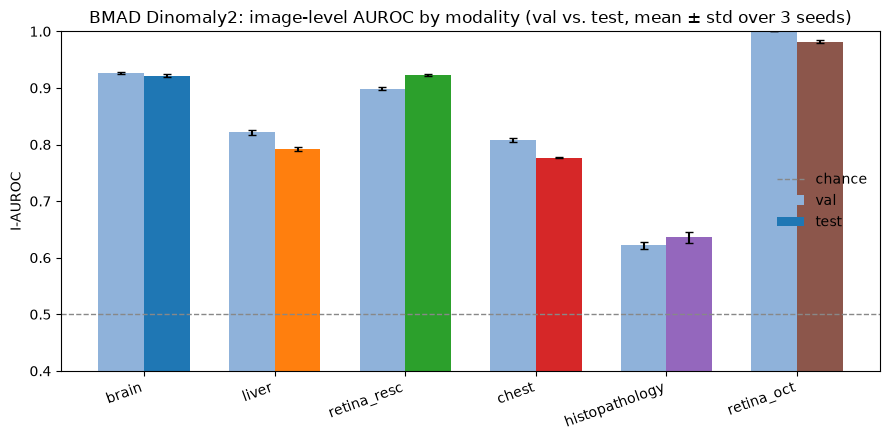

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
present = results.index[results['test_I_AUROC_mean'].notna()]
x = np.arange(len(present))
width = 0.35
ax.bar(x - width/2, results.loc[present, 'val_I_AUROC_mean'], width,
       yerr=results.loc[present, 'val_I_AUROC_std'], capsize=3, label='val', color='#8fb2da')
ax.bar(x + width/2, results.loc[present, 'test_I_AUROC_mean'], width,
       yerr=results.loc[present, 'test_I_AUROC_std'], capsize=3,
       color=[PALETTE[m] for m in present], label='test')
ax.set_xticks(x)
ax.set_xticklabels(present, rotation=20, ha='right')
ax.set_ylabel('I-AUROC')
ax.set_ylim(0.4, 1.0)
ax.axhline(0.5, color='#888888', lw=1, ls='--', label='chance')
ax.set_title(f'BMAD Dinomaly2: image-level AUROC by modality (val vs. test, mean ± std over {len(SEEDS)} seeds)')
ax.legend(frameon=False)
fig.tight_layout()

**Analysis.** The error bars make the same three-tier grouping visible at a glance,
and are tight enough everywhere except Histopathology that val and test bars within a
modality are easy to compare directly. RESC is the one modality where the val bar is
visibly shorter than the test bar (0.899 vs. 0.923), the pessimistic bias from
sections 4 and 6. OCT's val bar sits at exactly 1.0 with no visible error bar at all
(every one of the three seeds achieved perfect val separation), while its test bar is
clearly shorter (0.982) and does carry a real error bar -- the clearest single piece
of evidence in this chart for the 32-image val split being too small to serve as a
reliable ceiling. Liver and Chest both show a smaller, same-direction gap (val
running about three points above test for each), which is a mild optimistic bias
rather than the pessimistic one RESC shows, and small enough relative to the error
bars not to be worth separate flagging. Histopathology's bar pair has the widest error
bars of the six by a clear margin and sits closest to the chance line, underscoring
that it is a qualitatively noisier result rather than just the low end of a continuum.

## 6. Findings

The analysis in sections 4 and 5 resolves the questions this section originally posed,
now confirmed across three independent seeds rather than read off a single run:

- **Convergence.** Brain, RESC, and OCT are stable well before iteration 5000 in every
  seed. Liver is not flat but peaks at iteration 2000 and drifts down afterward in all
  three seeds -- mild overfitting past that point, not an undertraining problem.
  Histopathology is flat and noisy throughout, with no two seeds even agreeing on
  which checkpoint was best, so more iterations at the current architecture would not
  be expected to close its gap to the top tier. Chest is the one modality whose test
  I-AUROC is still rising at iteration 5000 in every seed and is the best candidate
  for a longer run before drawing conclusions about it.
- **Val/test tracking.** RESC (val below test, a pessimistic bias) and OCT (val
  reaching exactly 1.0 in every seed on a 32-image split) are the two modalities with
  a persistent, seed-independent val/test gap. Seeing the same direction in all three
  seeds for both is stronger evidence for a structural explanation (RESC's val split
  understates performance; OCT's split is too small to be a reliable ceiling) than a
  single seed's result could offer.
- **OCT vs. RESC**, the closest same-domain pair in this benchmark (both retinal
  OCT): OCT's mean test I-AUROC (0.982) exceeds RESC's (0.923) by about six points.
  Since OCT lacks pixel masks and its val split is tiny, some of this is measurement
  noise, but a six-point gap, consistent across three seeds, is unlikely to be fully
  explained by that alone. Brain and RESC, by contrast, turn out not to be separated
  at all once seed variance is accounted for (section 5) -- a distinction the
  single-seed pilot could not have drawn.

Histopathology is the clear outlier: roughly 14 points of mean test I-AUROC below the
next-weakest modality, flat across all of training in every seed, and by far the
noisiest modality in section 5's table, which together point to a representation
mismatch rather than a training budget problem. Section 7 investigates this with a
targeted architecture change, per the advisor's note that architecture changes are
the natural next step once these baseline numbers are established.

## 7. Architecture iteration: shallow encoder layers for Histopathology

Histopathology is the one modality where the baseline architecture is not the right tool for the domain, rather than a modality that simply needs more training. Two properties distinguish it from the other five:

- **No canonical structure.** Brain, Liver, Chest, RESC, and OCT all have a consistent global layout: a brain slice, an abdominal CT slice, a chest X-ray, a retinal cross-section. Anomalies in these modalities are largely deviations from that shared layout (a lesion, an opacity, a structural break), which is exactly what DINOv2's mid-to-late encoder layers are trained to represent, since those layers are increasingly pooled toward object- and scene-level semantics. A Camelyon16 histopathology patch has no such layout: wherever it is cropped from a slide, it is homogeneous cellular tissue, and the anomaly (tumor vs. normal tissue) is a difference in local texture statistics, cell density, and nuclear morphology, not in global shape.
- **Native resolution.** Confirmed below, Histopathology's source patches are natively 256x256 RGB, the smallest of any BMAD modality. The training pipeline resizes every modality to a shared 448px (crop 392px), which for Histopathology means upsampling by roughly 1.7x before the encoder ever sees the image, on top of features that are already biased away from fine local texture.

DINOv2's self-supervised pretraining objective encourages exactly the kind of semantic invariance that works against this domain: representations that are stable across local texture and lighting variation are useful for recognizing an object as "the same object," but that same invariance discards the fine-grained statistics Histopathology's anomaly signal depends on. This is consistent with section 4's finding that Histopathology's test I-AUROC is flat and noisy across all 5000 training iterations rather than improving: the bottleneck and decoder cannot learn to separate normal from abnormal tissue from features that have already discarded the relevant signal, so no amount of additional training against this target closes the gap.

**Change.** `build_dinomaly2` and `BMADConfig` (`src/models/dinomaly2.py`, `src/training/train_bmad.py`) were extended with a `target_layers` override. This run swaps Histopathology's reconstruction target from the default `[2, 3, 4, 5, 6, 7, 8, 9]` (mid-depth, semantically pooled) to a shallow-biased `[0, 1, 2, 3, 4, 5, 6, 7]` (closer to the patch embedding, away from the two most semantically pooled layers), holding every other hyperparameter identical to the section 3 baseline for a controlled comparison.

In [9]:
from PIL import Image

for name, cfg in MODALITY_CONFIGS.items():
    sample = sorted((bmad_root / cfg.subpath / 'train' / 'good').glob('*'))[0]
    with Image.open(sample) as im:
        print(f'{name:16s}  native size {im.size}  mode {im.mode}')

brain             native size (240, 240)  mode RGBA
liver             native size (512, 512)  mode L
retina_resc       native size (512, 1024)  mode L
chest             native size (1024, 1024)  mode L
histopathology    native size (256, 256)  mode RGB
retina_oct        native size (512, 496)  mode RGB


Histopathology's 256x256 is the smallest native resolution in the benchmark; Brain's 240x240 is close in raw pixel count but is an MRI slice with a clear anatomical layout, which is the structural distinction the hypothesis above rests on rather than resolution alone.

The cell below reruns the same `train()` call as section 3, with `target_layers` overridden and a fixed `out_dir` (not timestamped) so it does not collide with the modality-keyed glob `load_history` uses in section 3, keeping this experiment's results separate from the baseline history loaded there. It uses a single seed (`SEEDS[0]`) rather than the full seed sweep: this is a controlled comparison against the baseline's same seed, not a headline number, so it does not need the mean-over-seeds treatment section 3/5 apply. Expect roughly 100 minutes for 5000 iterations, matching Histopathology's section 3 per-seed runtime; the progress bar and per-checkpoint val/test lines print the same way section 3's training does. Safe to interrupt and rerun, same as section 3: the fallback cell after it reloads `history.json` from disk for a kernel restart without retraining.

In [10]:
SHALLOW_TARGET_LAYERS = [0, 1, 2, 3, 4, 5, 6, 7]  # vs. default [2..9] of vit_base's 12 DINOv2 blocks
SHALLOW_OUT_DIR = 'bmad_arch_iter_histopathology_shallow_layers'

# Single seed: this is a targeted hypothesis test against one baseline seed
# (SEEDS[0]), not a headline number requiring seed-averaging.
shallow_cfg = BMADConfig(
    modality='histopathology', backbone=BACKBONE, total_iters=TOTAL_ITERS, eval_every=EVAL_EVERY,
    warmup_iters=WARMUP, seed=SEEDS[0], target_layers=SHALLOW_TARGET_LAYERS,
    out_dir=f'../../runs/{SHALLOW_OUT_DIR}',
)
shallow_history = train(shallow_cfg, device=device)

device mps | modality histopathology (pixel masks: False) | backbone vit_base | trainable 60.0M
train images 5088 | val images 236 | test images 1997 | 318 batches/epoch -> 16 epochs
-> ../../runs/bmad_arch_iter_histopathology_shallow_layers


  0%|          | 0/5000 [00:00<?, ?it/s]

[eval @ iter 1000 / epoch 4] val: I-AUROC 0.6030  I-AP 0.5624  I-F1 0.6984
                             test: I-AUROC 0.5803  I-AP 0.5361  I-F1 0.6938
[eval @ iter 2000 / epoch 7] val: I-AUROC 0.5908  I-AP 0.5525  I-F1 0.6903
                             test: I-AUROC 0.5867  I-AP 0.5408  I-F1 0.6999
[eval @ iter 3000 / epoch 10] val: I-AUROC 0.5963  I-AP 0.5900  I-F1 0.6751
                              test: I-AUROC 0.5715  I-AP 0.5318  I-F1 0.6916
[eval @ iter 4000 / epoch 13] val: I-AUROC 0.5874  I-AP 0.5480  I-F1 0.6987
                              test: I-AUROC 0.5879  I-AP 0.5392  I-F1 0.6992
[eval @ iter 5000 / epoch 16] val: I-AUROC 0.5906  I-AP 0.5699  I-F1 0.6926
                              test: I-AUROC 0.5781  I-AP 0.5310  I-F1 0.6952
done in 98.1 min  ->  ../../runs/bmad_arch_iter_histopathology_shallow_layers


In [11]:
def load_fixed_history(history_or_none, rel_out_dir):
    if history_or_none is not None:
        return history_or_none
    path = f'../../runs/{rel_out_dir}/history.json'
    if not glob.glob(path):
        return None
    return json.load(open(path))

shallow_history = load_fixed_history(globals().get('shallow_history'), SHALLOW_OUT_DIR)
status = f"{len(shallow_history['evals'])} eval checkpoint(s)" if shallow_history else 'no run found on disk yet'
print(f'histopathology (shallow layers)  {status}')

histopathology (shallow layers)  5 eval checkpoint(s)


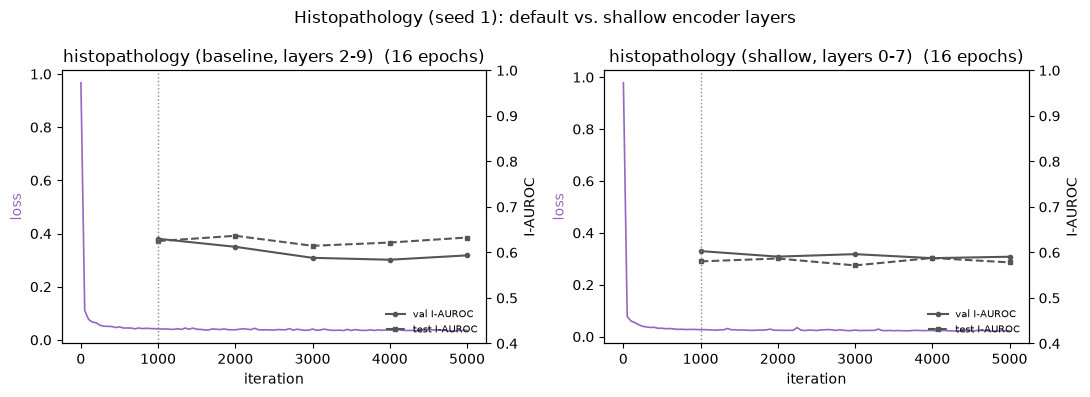

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_history(axes[0], histories['histopathology'][SEEDS[0]], 'histopathology (baseline, layers 2-9)', color=PALETTE['histopathology'])
plot_history(axes[1], shallow_history, 'histopathology (shallow, layers 0-7)', color=PALETTE['histopathology'])
fig.suptitle(f'Histopathology (seed {SEEDS[0]}): default vs. shallow encoder layers')
fig.tight_layout()

In [13]:
def summarize(history, label):
    e = best_eval(history)
    if e is None:
        return None
    return dict(variant=label, best_iter=e['iter'], val_I_AUROC=e['val']['auroc_sp'],
                test_I_AUROC=e['test']['auroc_sp'], test_I_AP=e['test']['ap_sp'], test_I_F1=e['test']['f1_sp'])

comparison = pd.DataFrame([r for r in [
    summarize(histories['histopathology'][SEEDS[0]], f'baseline (layers 2-9, seed {SEEDS[0]})'),
    summarize(shallow_history, f'shallow (layers 0-7, seed {SEEDS[0]})'),
] if r is not None]).set_index('variant')
comparison

,best_iter,val_I_AUROC,test_I_AUROC,test_I_AP,test_I_F1
variant,,,,,
"baseline (layers 2-9, seed 1)",1000,0.630037,0.624980,0.570091,0.704683
"shallow (layers 0-7, seed 1)",1000,0.602959,0.580346,0.536059,0.693833


**Analysis.** The shallow-layer run finished with a test I-AUROC of 0.580 at its own `best_val_iter` (1000), against 0.625 for the baseline at the same iteration: a drop of 4.5 points, not a gain. Looking at the full curve rather than a single checkpoint makes this more convincing, not less: shallow's test I-AUROC stays in a 0.572-0.588 band across all five checkpoints, and baseline's stays in a 0.615-0.637 band; the two ranges never overlap. This is a consistent, checkpoint-independent drop, not a fluke of which iteration got selected. The layer-depth hypothesis is rejected as stated: moving the reconstruction target to shallower layers made Histopathology worse, not better.

This fits a pattern documented elsewhere in ViT representation-probing work: a self-supervised encoder's most task-general features tend to peak in its middle layers, with both the earliest layers (close to raw patch embeddings, not yet contextualized by attention) and the latest layers (compressed toward whatever the pretraining objective specifically optimized) scoring worse on downstream probes. Dinomaly2's default `[2..9]` was evidently not an arbitrary MVTec-specific choice that could safely be moved away from; it likely sits near the general-purpose optimum for this encoder, and shifting toward layer 0 traded away that optimum without buying back any texture sensitivity in return. The shallow run's own curve is also still flat and noisy across all five checkpoints, the same pattern the baseline showed, so this is not an undertraining problem either.

This is read as evidence that encoder depth is not where Histopathology's gap comes from. The domain-mismatch explanation from this section's introduction, DINOv2 pretrained on natural images versus H&E-stained tissue, still stands; what this result rules out is that the fix is a free architectural knob. The more targeted next step is addressing the input distribution directly: stain-color normalization or stain-augmentation during training, the standard computational-pathology mitigation for exactly this kind of pretrained-encoder domain gap, rather than another reconstruction-target change on the same frozen features. Section 8 provides independent evidence for this same conclusion from an entirely different method.

## 8. AnomalyDINO-DPMM: a frozen-feature baseline (Schulthess & Konukoglu, MICCAI 2025)

Per the advisor's follow-up instructions: train and evaluate
[AnomalyDINO-DPMM](https://papers.miccai.org/miccai-2025/paper/2425_paper.pdf) on BMAD,
from scratch (not just inference from a pretrained checkpoint). Code adapted from the
official release, vendored at `anomalydino-dpmm/` (itself built on
[AnomalyDINO](https://github.com/dammsi/AnomalyDINO), Apache 2.0; the anomalydino-dpmm
repo itself is CC-BY-NC 4.0):

> Schulthess, N. and Konukoglu, E., "Anomaly Detection by Clustering DINO Embeddings
> using a Dirichlet Process Mixture", MICCAI 2025.
>
> ```bibtex
> @InProceedings{Schulthess2025Anomaly,
>     author = {Schulthess, Nico and Konukoglu, Ender},
>     title = {{Anomaly Detection by Clustering DINO Embeddings using a
>               Dirichlet Process Mixture}},
>     booktitle = {MICCAI 2025},
>     year = {2025},
> }
> ```

**This is a different family of method from sections 1-7, not a variant of Dinomaly2:**
there is no trainable encoder/decoder and no backpropagation. A frozen DINOv2 backbone
(`dinov2_vits14`, matching the paper's own reference configs -- not the `vitb14_reg`
backbone sections 1-7 use) extracts per-patch embeddings; "training" fits a truncated
stick-breaking Dirichlet Process Mixture (`src/models/dpmm.py`) to the normal training
patches via online EM -- each `dpmm.step()` is one batch's E/M update, with an
exponentially-weighted running average of the sufficient statistics
(`update_rate`/`schedule`), rather than gradient descent. At test time, a patch's
anomaly score is its negative log-likelihood under the fitted mixture; image/pixel maps
and metrics are built from that score the same way sections 1-7 build them from
Dinomaly2's cosine-distance map (`src/eval/bmad_dpmm.py`, mirroring `src/eval/bmad.py`'s
image-only vs. image+pixel split).

**Implementation note.** The reference implementation evaluates each Gaussian
component's log-density via the general (dense) `MultivariateNormal` machinery, which
is O(N x K x D^2) per batch -- tractable on the paper's presumed CUDA cluster, but
prohibitively slow off one at K=500 (the paper's own truncation level) and D=384
(vits14). `src/models/dpmm.py` adds a closed-form diagonal-Gaussian log-density path
(`_diag_gaussian_log_prob`), used whenever `cov_type` is `"diag"` or `"spherical"` (the
default here, and what most of the paper's own BMAD configs use) -- mathematically
identical to the dense path (verified directly against it), just O(N x K x D) instead of
O(N x K x D^2), which is what keeps fitting all six modalities tractable on a single
Mac (MPS). Switching `cov_type` to `"full"` reintroduces the O(D^2) cost.

Same val/test protocol as sections 1-7: val picks the checkpoint (`best_checkpoint.pt`,
by val I-AUROC), test is what gets reported.

In [14]:
DPMM_BACKBONE = 'dinov2_vits14'
DPMM_COV_TYPE = 'diag'

if DEV:
    DPMM_EPOCHS, DPMM_EVAL_EVERY, DPMM_MAX_COMPONENTS = 2, 1, 20
else:
    DPMM_EPOCHS, DPMM_EVAL_EVERY, DPMM_MAX_COMPONENTS = 40, 5, 500

print(f'dpmm_backbone: {DPMM_BACKBONE} | cov_type: {DPMM_COV_TYPE}')
print(f'dpmm_epochs: {DPMM_EPOCHS} | eval_every_epochs: {DPMM_EVAL_EVERY} | max_num_components: {DPMM_MAX_COMPONENTS}')

dpmm_backbone: dinov2_vits14 | cov_type: diag
dpmm_epochs: 40 | eval_every_epochs: 5 | max_num_components: 500


In [15]:
from src.training.train_bmad_dpmm import BMADDPMMConfig, train as train_dpmm

dpmm_histories = {name: {} for name in MODALITIES}
for name in MODALITIES:
    for seed in SEEDS:
        print(f'=== {name} (AnomalyDINO-DPMM, seed {seed}) ===')
        cfg = BMADDPMMConfig(
            modality=name, backbone=DPMM_BACKBONE, epochs=DPMM_EPOCHS, eval_every_epochs=DPMM_EVAL_EVERY,
            max_num_components=DPMM_MAX_COMPONENTS, cov_type=DPMM_COV_TYPE, seed=seed,
        )
        dpmm_histories[name][seed] = train_dpmm(cfg, device=device)

=== brain (AnomalyDINO-DPMM, seed 1) ===
device mps | modality brain (pixel masks: True) | backbone dinov2_vits14 (frozen, 22.1M params) | D=384 | K=500
train images 7500 | val images 83 | test images 3715 | 938 batches/epoch -> 40 epochs
-> /Users/toriav/Desktop/Erem/BC Cancer/Anomaly Detection/mammo-uad-2d3d/runs/bmad_dpmm_brain_seed1_20260930_042232


  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/938 [00:03<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

...

  0%|          | 0/3290 [00:00<?, ?it/s]

  0%|          | 0/3290 [00:00<?, ?it/s]

  0%|          | 0/3290 [00:00<?, ?it/s]

  0%|          | 0/3290 [00:00<?, ?it/s]

[eval @ epoch 40] val: I-AUROC 0.7969  I-AP 0.9113  I-F1 0.9231
                  test: I-AUROC 0.8224  I-AP 0.9216  I-F1 0.8795
done in 672.1 min  ->  /Users/toriav/Desktop/Erem/BC Cancer/Anomaly Detection/mammo-uad-2d3d/runs/bmad_dpmm_retina_oct_seed3_20261002_221953


### Results

Same reload-from-disk pattern as section 3: safe to interrupt and rerun, and works from
a fresh kernel by falling back to the latest `runs/bmad_dpmm_<modality>_seed<seed>_*`
on disk. `dpmm_histories` is keyed `dpmm_histories[modality][seed]`, same as section 3.

In [16]:
def load_dpmm_history(history_or_none, modality, seed):
    if history_or_none is not None:
        return history_or_none
    matches = sorted(glob.glob(f'../../runs/bmad_dpmm_{modality}_seed{seed}_*'))
    if not matches:
        return None
    return json.load(open(f'{matches[-1]}/history.json'))

dpmm_histories = {
    name: {seed: load_dpmm_history(dpmm_histories.get(name, {}).get(seed), name, seed) for seed in SEEDS}
    for name in MODALITIES
}
for name in MODALITIES:
    parts = [f"seed {seed}: {len(h['evals'])} eval checkpoint(s)" if h else f"seed {seed}: no run yet"
             for seed, h in dpmm_histories[name].items()]
    print(f'{name:16s}  ' + ' | '.join(parts))

brain             seed 1: 8 eval checkpoint(s) | seed 2: 8 eval checkpoint(s) | seed 3: 8 eval checkpoint(s)
liver             seed 1: 8 eval checkpoint(s) | seed 2: 8 eval checkpoint(s) | seed 3: 8 eval checkpoint(s)
retina_resc       seed 1: 8 eval checkpoint(s) | seed 2: 8 eval checkpoint(s) | seed 3: 8 eval checkpoint(s)
chest             seed 1: 8 eval checkpoint(s) | seed 2: 8 eval checkpoint(s) | seed 3: 8 eval checkpoint(s)
histopathology    seed 1: 8 eval checkpoint(s) | seed 2: 8 eval checkpoint(s) | seed 3: 8 eval checkpoint(s)
retina_oct        seed 1: 8 eval checkpoint(s) | seed 2: 8 eval checkpoint(s) | seed 3: 8 eval checkpoint(s)


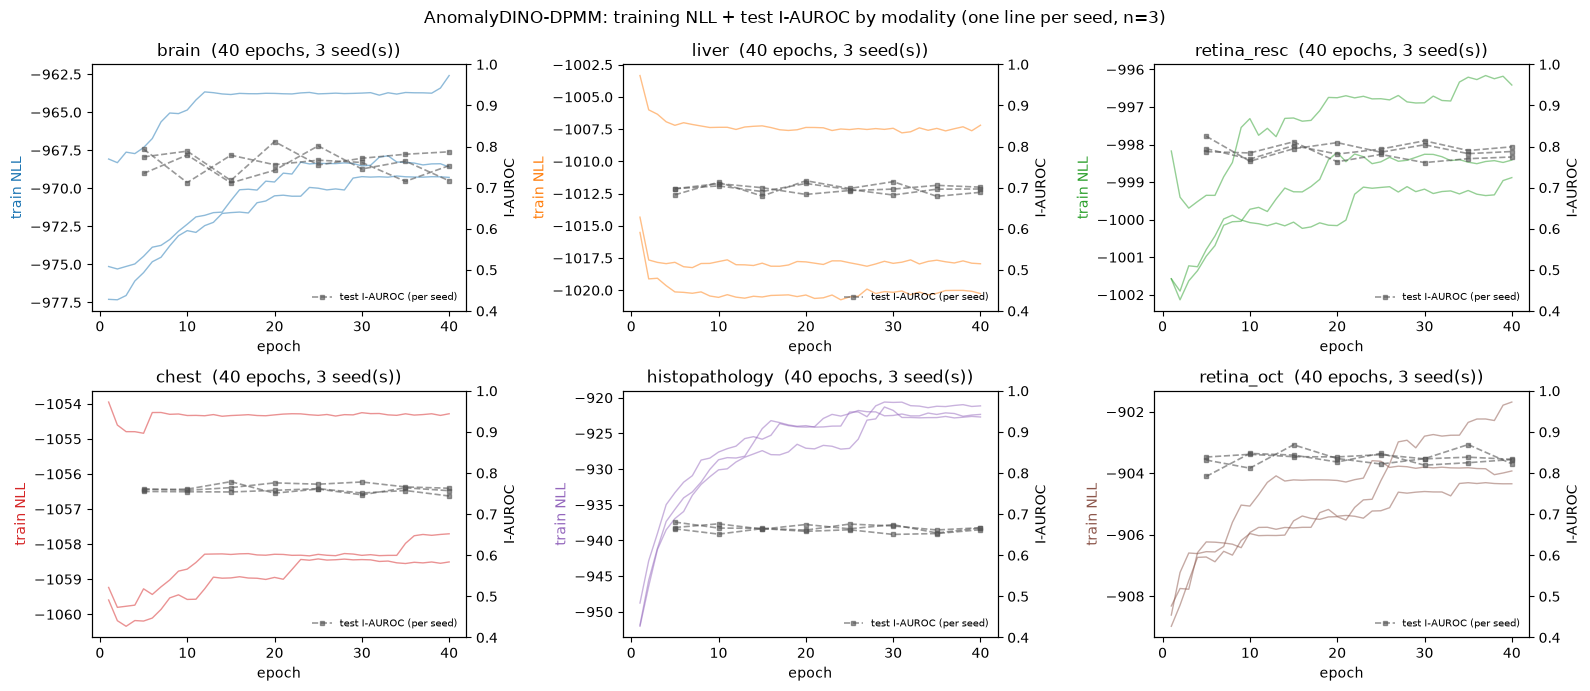

In [17]:
def plot_dpmm_seed_histories(ax, seed_histories, name, color=None):
    """Same structure as plot_seed_histories (section 4), x-axis in epochs and
    left-axis label 'train NLL' rather than 'loss', matching DPMM's own units."""
    color = color or PALETTE.get(name, '#4c72b0')
    valid = {s: h for s, h in seed_histories.items() if h and h['iters']}
    if not valid:
        ax.set_title(f'{name}: no data yet')
        return
    for h in valid.values():
        ax.plot(h['iters'], h['loss'], color=color, lw=1.0, alpha=0.5)
    ax.set_xlabel('epoch')
    ax.set_ylabel('train NLL', color=color)
    any_h = next(iter(valid.values()))
    ax.set_title(f"{name}  ({len(any_h['iters'])} epochs, {len(valid)} seed(s))")

    ax2 = ax.twinx()
    for i, h in enumerate(valid.values()):
        if h['evals']:
            eval_iters = [e['iter'] for e in h['evals']]
            ax2.plot(eval_iters, [e['test']['auroc_sp'] for e in h['evals']],
                      color='#555555', lw=1.2, ls='--', marker='s', ms=3, alpha=0.6,
                      label='test I-AUROC (per seed)' if i == 0 else None)
    ax2.set_ylabel('I-AUROC')
    ax2.set_ylim(0.4, 1.0)
    handles, labels = ax2.get_legend_handles_labels()
    if handles:
        ax2.legend(fontsize=7, frameon=False, loc='lower right')

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, name in zip(axes.flat, MODALITIES):
    plot_dpmm_seed_histories(ax, dpmm_histories.get(name, {}), name)
fig.suptitle(f'AnomalyDINO-DPMM: training NLL + test I-AUROC by modality (one line per seed, n={len(SEEDS)})')
fig.tight_layout()

In [18]:
dpmm_rows = []
for name in MODALITIES:
    row = summarize_across_seeds(dpmm_histories.get(name, {}))  # defined in section 5
    if row is None:
        continue
    row['modality'] = name
    row['has_masks'] = MODALITY_CONFIGS[name].has_masks
    dpmm_rows.append(row)

dpmm_results = pd.DataFrame(dpmm_rows).set_index('modality')
dpmm_results[display_cols]  # display_cols defined in section 5

,has_masks,n_seeds,best_iter,val_I_AUROC,test_I_AUROC,val_I_AP,test_I_AP,val_I_F1,test_I_F1,test_P_AUROC,test_P_AP,test_P_F1,test_P_AUPRO
modality,,,,,,,,,,,,,
brain,True,3,"5, 5, 10",0.8102 ± 0.0069 (n=3),0.7828 ± 0.0082 (n=3),0.8436 ± 0.0087 (n=3),0.9271 ± 0.0031 (n=3),0.7829 ± 0.0048 (n=3),0.9185 ± 0.0005 (n=3),0.9359 ± 0.0028 (n=3),0.3122 ± 0.0177 (n=3),0.4339 ± 0.0143 (n=3),0.6736 ± 0.0054 (n=3)
liver,True,3,"20, 20, 10",0.7032 ± 0.0029 (n=3),0.7123 ± 0.0033 (n=3),0.6550 ± 0.0034 (n=3),0.6312 ± 0.0084 (n=3),0.6524 ± 0.0015 (n=3),0.6648 ± 0.0027 (n=3),0.9547 ± 0.0006 (n=3),0.1257 ± 0.0080 (n=3),0.2110 ± 0.0060 (n=3),0.9153 ± 0.0002 (n=3)
retina_resc,True,3,"5, 15, 40",0.7764 ± 0.0097 (n=3),0.8120 ± 0.0105 (n=3),0.8143 ± 0.0248 (n=3),0.7251 ± 0.0201 (n=3),0.8212 ± 0.0155 (n=3),0.7251 ± 0.0182 (n=3),0.8741 ± 0.0023 (n=3),0.3404 ± 0.0057 (n=3),0.4228 ± 0.0076 (n=3),0.5817 ± 0.0079 (n=3)
chest,False,3,"35, 15, 20",0.7980 ± 0.0125 (n=3),0.7709 ± 0.0096 (n=3),0.9858 ± 0.0016 (n=3),0.9821 ± 0.0012 (n=3),0.9765 ± 0.0002 (n=3),0.9769 ± 0.0000 (n=3),NaN,NaN,NaN,NaN
histopathology,False,3,"30, 25, 5",0.6400 ± 0.0031 (n=3),0.6647 ± 0.0105 (n=3),0.5735 ± 0.0085 (n=3),0.5910 ± 0.0086 (n=3),0.7226 ± 0.0023 (n=3),0.7154 ± 0.0049 (n=3),NaN,NaN,NaN,NaN
retina_oct,False,3,"25, 5, 35",0.8941 ± 0.0123 (n=3),0.8521 ± 0.0127 (n=3),0.9592 ± 0.0055 (n=3),0.9356 ± 0.0062 (n=3),0.9351 ± 0.0085 (n=3),0.8859 ± 0.0072 (n=3),NaN,NaN,NaN,NaN


In [19]:
comparison_i_auroc = pd.DataFrame({
    'Dinomaly2 (test I-AUROC)': results['test_I_AUROC'],
    'AnomalyDINO-DPMM (test I-AUROC)': dpmm_results['test_I_AUROC'],
})
comparison_i_auroc['delta of means (DPMM - Dinomaly2)'] = (
    dpmm_results['test_I_AUROC_mean'] - results['test_I_AUROC_mean']
)
comparison_i_auroc.sort_values('delta of means (DPMM - Dinomaly2)', ascending=False)

,Dinomaly2 (test I-AUROC),AnomalyDINO-DPMM (test I-AUROC),delta of means (DPMM - Dinomaly2)
modality,,,
histopathology,0.6362 ± 0.0097 (n=3),0.6647 ± 0.0105 (n=3),0.028497
chest,0.7768 ± 0.0006 (n=3),0.7709 ± 0.0096 (n=3),-0.005935
liver,0.7922 ± 0.0039 (n=3),0.7123 ± 0.0033 (n=3),-0.079848
retina_resc,0.9226 ± 0.0011 (n=3),0.8120 ± 0.0105 (n=3),-0.110626
retina_oct,0.9816 ± 0.0025 (n=3),0.8521 ± 0.0127 (n=3),-0.129535
brain,0.9216 ± 0.0032 (n=3),0.7828 ± 0.0082 (n=3),-0.138881


**Analysis.** The comparison table's deltas, read against each method's own
seed-to-seed std rather than at face value, split cleanly into three groups.

**Four modalities show a large, clearly real gap favoring Dinomaly2.** Liver (-8.0
points), RESC (-11.1), OCT (-13.0), and Brain (-13.9) all have gaps several times
larger than either method's std on that modality (e.g. Brain's 13.9-point gap against
stds of 0.3 and 0.8 points for Dinomaly2 and DPMM respectively). Trained reconstruction
is recovering real signal that a Gaussian mixture over the same frozen embeddings
cannot reach on its own, on exactly the modalities where DINOv2's representations
encode useful anatomical structure (Brain, RESC, and OCT are the "structure-bearing"
tier from section 5).

**Chest is a tie, not a small Dinomaly2 win.** The gap (-0.6 points) is smaller than
DPMM's own std on Chest (1.0 point), so it is not distinguishable from seed noise.
Both methods land around 0.77-0.78 test I-AUROC there.

**Histopathology favors DPMM, modestly but plausibly.** The gap (+2.8 points, DPMM
ahead) is about three times the larger of the two stds (DPMM's 1.1 points), a real if
not dramatic difference. More importantly, Histopathology is DPMM's own lowest score
across all six modalities (0.665), the same relative ranking Dinomaly2 showed in
section 5. A method with no trained decoder at all, scoring anomalies purely from
where a frozen DINOv2 patch embedding falls in a clustering of normal embeddings,
bottoms out on the same modality as a method that spends 5000 gradient steps learning
to reconstruct DINOv2 features for that modality -- and does so across three
independent seeds of each method, six runs in total pointing the same way. That is
meaningfully independent evidence for section 7's conclusion: the ceiling on
Histopathology is set by what DINOv2's ImageNet-style pretraining encodes for
H&E-stained tissue, not by anything specific to Dinomaly2's reconstruction objective
or its choice of target layers.

**DPMM's checkpoint selection is noisy in a way that reframes the single-seed pilot's
caution about "late" checkpoints.** Rather than a few modalities needing a longer
budget, DPMM's val I-AUROC oscillates up and down across epochs for every modality in
every seed, never settling into the smooth, mostly-monotonic shape Dinomaly2's curves
show in section 4. `best_val_iter` lands anywhere from epoch 5 to epoch 40 depending
on the seed, for every modality (Brain: 5, 5, 10; Liver: 20, 20, 10; RESC: 5, 15, 40;
Chest: 35, 15, 20; Histopathology: 30, 25, 5; OCT: 25, 5, 35) -- consistent with
picking whichever epoch's noise happened to spike on that seed's validation split,
not with genuine late-stage convergence. The std columns in section 5's table and this
section's table show the same thing from a different angle: DPMM's seed-to-seed std is
larger than Dinomaly2's on five of the six modalities -- clearly so on Brain, RESC,
Chest, and OCT, only marginally on Histopathology -- and the sole exception is Liver,
where DPMM's std is actually slightly smaller than Dinomaly2's.

Two of the val/test asymmetries flagged for Dinomaly2 in section 4 and 6 reappear
under DPMM, now with three seeds of each method rather than one: RESC's val I-AUROC
(0.776) sits below its test I-AUROC (0.812), and OCT's val I-AUROC (0.894) sits above
its test I-AUROC (0.852), the same direction as their respective Dinomaly2 asymmetries.
Reproducing under an architecturally unrelated method, across three seeds of each, is
substantially stronger evidence for section 6's explanation (RESC's val split
understating performance; OCT's 32-image val split being too small to be a reliable
ceiling) than either method's result could offer alone.